# Explainable Credit Risk Assessment

## 1. Load the Data
- We will bring in the loan applicant data.
- This data has details like income, age, and loan amount.
- It also tells us who repaid and who defaulted.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Exploratory Data Analysis (EDA)
- Here we simply look at the data before touching it.
- We want to understand it first, then work on it.

### Basic info about the data
- Check how many rows and columns we have.
- Check the data type of each column.

In [3]:
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


### Missing values
- Find out which columns have empty or missing values.
- This tells us where we may need to fix things later.

In [4]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Target balance
- Check how many people defaulted vs how many repaid.
- This tells us if our data is balanced or imbalanced.

In [5]:
df.head()
df['loan_status'].unique()

df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

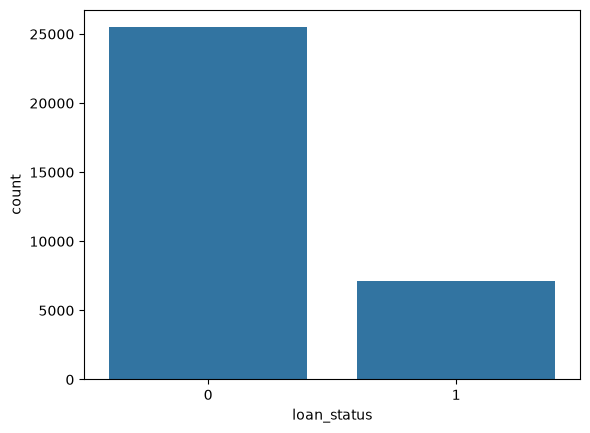

In [6]:
sns.countplot(x='loan_status', data=df)

### Outlier check
- Look for values that seem impossible, like age 144.
- These are signs of bad data entries.

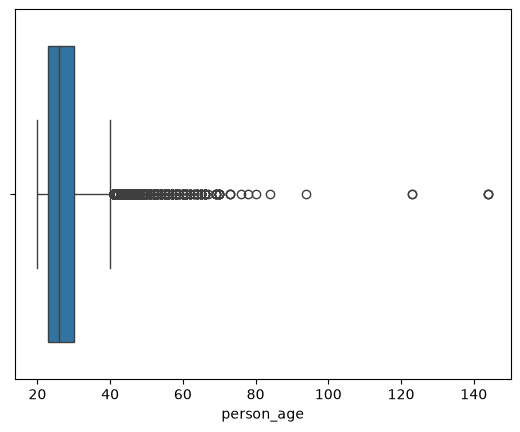

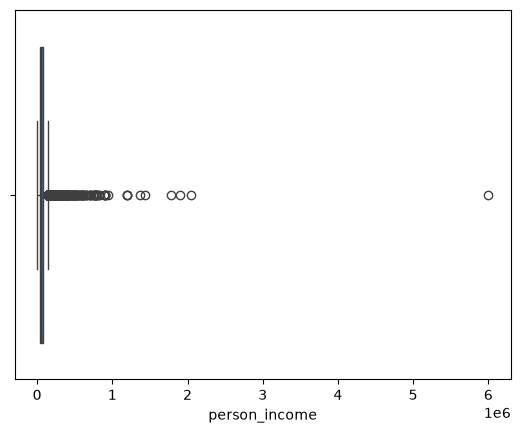

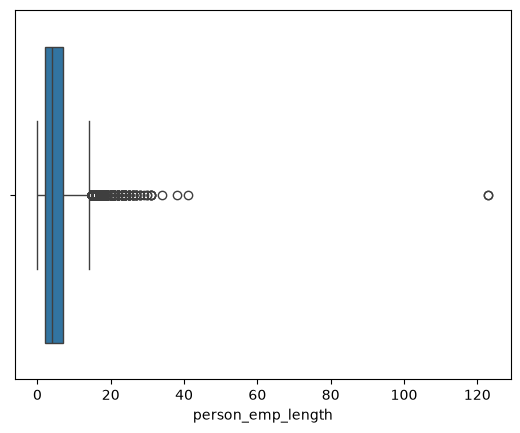

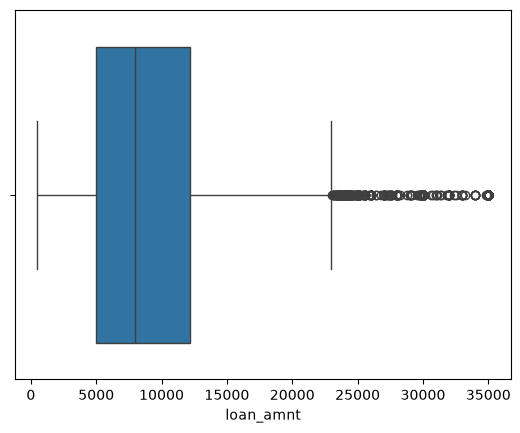

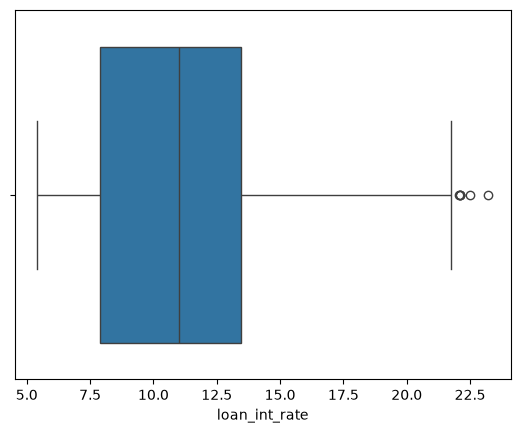

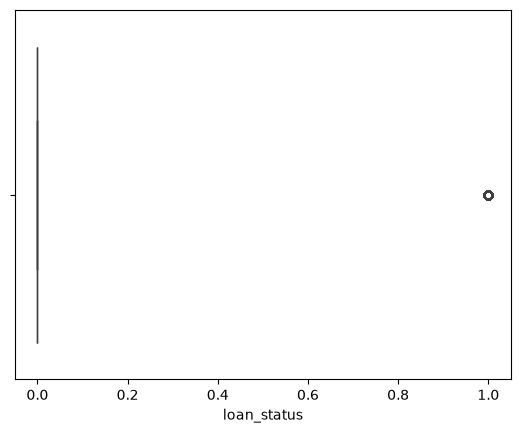

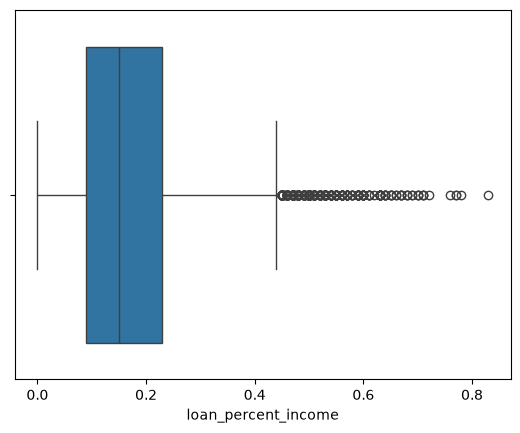

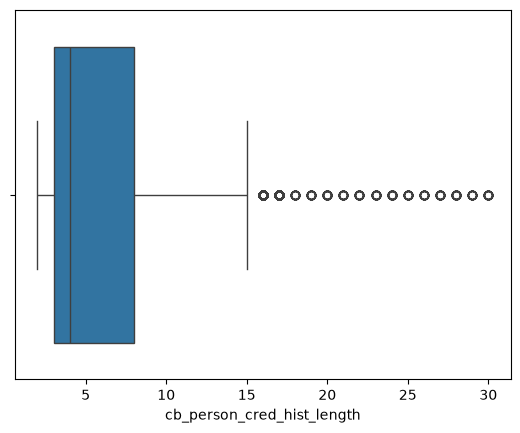

In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()



In [8]:
(df['person_age'] > 100).sum()

np.int64(5)

In [9]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [10]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Correlation check
- See how strongly features are related to each other.
- This helps us spot repeated or linked information.

<Axes: >

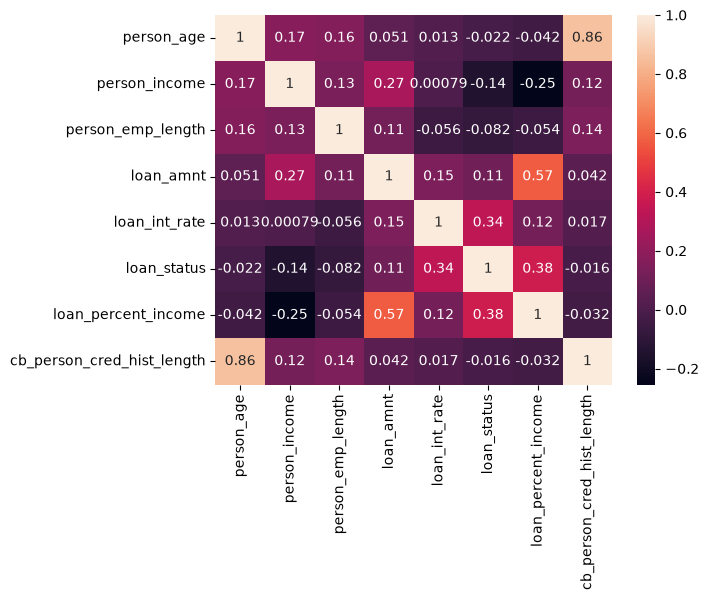

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## 3. Data Validation & Outlier Handling
- Here we clean the data properly.
- We remove duplicate rows.
- We remove rows with an impossible age or work experience.
- We remove rows with zero or negative income and loan amount.
- We check if the interest rate looks realistic.
- We also flag rows where numbers don't add up correctly.

In [12]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")

#Remove Duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

#Remove ages below 18 or below 100
df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]

#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

#check if the interest rate looks realistic.
print("Loan intreset rate range from (min: 5.42 and max: 23.22)")

Original Rows: 32581
Rows after removing duplicates : 32416
Loan intreset rate range from (min: 5.42 and max: 23.22)


## 4. Features, Target & Train-Test Split
- We separate the data into input features and the target.
- The target is whether the applicant defaulted or not.
- We split the data into a training part and a testing part.
- The model learns from the training part only.

In [13]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status'] #1, 0

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## 5. Handle Class Imbalance
- Very few people actually default in this data.
- If we ignore this, the model may just favor the majority class.
- We give more importance to the minority class during training.
- This helps the model actually learn to spot defaulters.

In [16]:
#0 -> no loan (most)
#1 -> yes loan

neg, pos = np.bincount(y_train)
scale_weigths = neg/pos

In [17]:
scale_weigths

np.float64(3.6312213039485766)

## 6. Data Preprocessing — Pipelines & Column Transformer
- Raw data is not ready for a model directly.
- We need to prepare numeric and text columns differently.
- We will build a Pipeline for each model.
- We will use ColumnTransformer to apply different steps to different columns.

### Preprocessing for Logistic Regression
- Fill missing numeric values.
- Scale numeric values, since this model is sensitive to scale.
- Convert category columns into numbers using one-hot encoding.

In [18]:
#Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


### Preprocessing for XGBoost
- Fill missing numeric values.
- No scaling needed here, since tree models don't need it.
- Convert category columns into numbers using one-hot encoding.

In [19]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


## 7. Evaluation Helper Function
- We build one common function to check any model's performance.
- It will show accuracy, precision, recall, F1 score, and more.
- It will also show a confusion matrix and a precision-recall curve.

In [20]:
#We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob >= threshold).astype(int)  # same rule as main.py
  else:
    y_pred = model.predict(X_test)

  #Metrics
  accuracy     = accuracy_score(y_test, y_pred)    #Overall model's preformance
  precision    = precision_score(y_test, y_pred)   #When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      #of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          #Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

## 8. Stratified Cross-Validation
- One single train-test split may not be reliable.
- We split the training data into five folds instead.
- Each fold keeps the same default vs repaid ratio.
- We check the model's score across all folds.

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [22]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

In [23]:
import pip
!pip install xgboost
#XGboost Model
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42
    ))
])

zsh:1: command not found: pip


In [24]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:

                      cv_results = cross_validate(pipe, X_train , y_train, cv=cv, scoring=scoring, n_jobs=-1)

                      print(cv_name)
                      print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                      print(f"Precision : {cv_results['test_precision'].mean()}")
                      print(f"Recall : {cv_results['test_recall'].mean()}")
                      print(f"F1 : {cv_results['test_f1'].mean()}")
                      print()

/private/tmp/claude-501/-Users-sumitjadhav-portfolio/87809726-a65c-4ea3-bf5f-272507e05bb2/scratchpad/fix/credit-risk-ml-system/.venv-nb/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/private/tmp/claude-501/-Users-sumitjadhav-portfolio/87809726-a65c-4ea3-bf5f-272507e05bb2/scratchpad/fix/credit-risk-ml-system/.venv-nb/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/private/tmp/claude-501/-Users-sumitjadhav-portfolio/87809726-a65c-4ea3-bf5f-272507e05bb2/scratchpad/fix/credit-risk-ml-system/.venv-nb/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/private/tmp/claude-501/-Users-sumitjadhav-portfolio/87809726-a65c-4ea3-bf5f-272507e05bb2/scratchpad/fix/credit-risk-ml-system/.venv-nb/lib/python3.12/

Logistic Regression
ROC-AUC : 0.8705112830525306
Accuracy : 0.8115949542892269
Precision : 0.5448226008889892
Recall : 0.7781450872359963
F1 : 0.6408013995933108



XGBoost
ROC-AUC : 0.9470945968526715
Accuracy : 0.917952083139717
Precision : 0.8190795992296656
Recall : 0.7963269054178144
F1 : 0.8073360762846882



## 9. Baseline Model — Logistic Regression
- We start with a simple model first.
- This becomes our benchmark to beat.
- We train it and check its score on the test data.

In [25]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight= "balanced"))
])
baseline_model.fit(X_train, y_train)

/private/tmp/claude-501/-Users-sumitjadhav-portfolio/87809726-a65c-4ea3-bf5f-272507e05bb2/scratchpad/fix/credit-risk-ml-system/.venv-nb/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

In [26]:
#Evaluate the Logistic Model.

Baseline Logistic Model Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



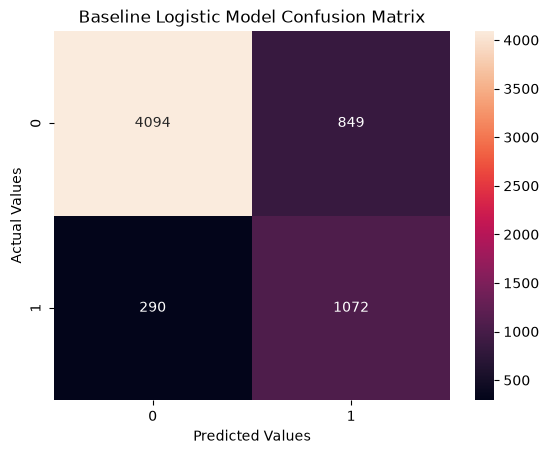

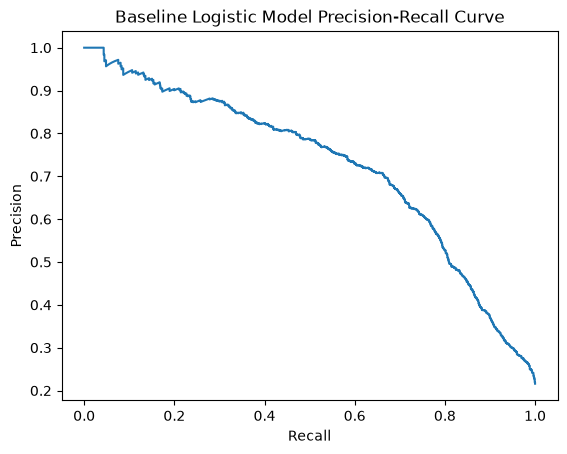

In [27]:
evaluate_model("Baseline Logistic Model", baseline_model ,X_test, y_test)

## 10. XGBoost Hyperparameter Tuning
- Now we move to a stronger model, XGBoost.
- A model has many settings called hyperparameters.
- We search for the best combination of these settings.
- We use cross-validation while searching, so the result is reliable.

In [28]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42))
])
xg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth" : randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}
# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting

In [30]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1,
    random_state=42,  # same search every run, so the saved model can be reproduced
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x11571d9a0>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x116016b10>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x1172d3980>},
                   random_state=42, scoring='average_precision', verbose=1)

In [31]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.90


In [32]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.8497416192535173),
 'classifier__gamma': np.float64(1.47816842918857),
 'classifier__learning_rate': np.float64(0.0627471299151353),
 'classifier__max_depth': 6,
 'classifier__min_child_weight': 4,
 'classifier__n_estimators': 435,
 'classifier__subsample': np.float64(0.9533121035675474)}

## 11. Compare Both Models Side by Side
- We now compare Logistic Regression and XGBoost.
- We look at their scores together in one table.
- This helps us pick the better performing model.

Logistic Regression Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



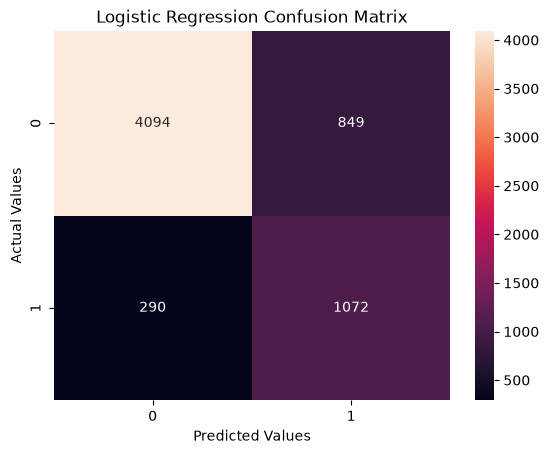

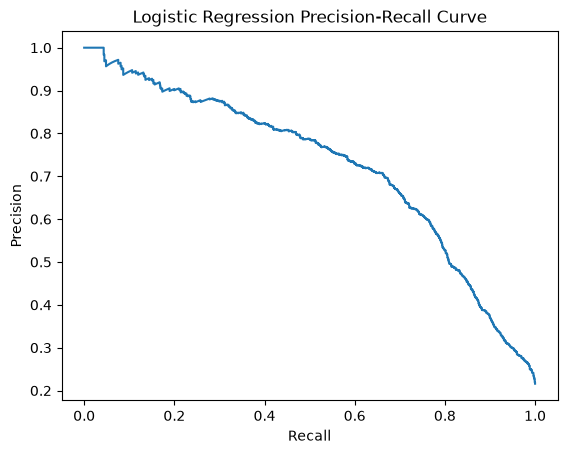

In [33]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)

XGBoost Metrics:
Accuracy : 0.92
Precision : 0.83
Recall : 0.81
F1 : 0.82

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4943
           1       0.83      0.81      0.82      1362

    accuracy                           0.92      6305
   macro avg       0.89      0.88      0.89      6305
weighted avg       0.92      0.92      0.92      6305



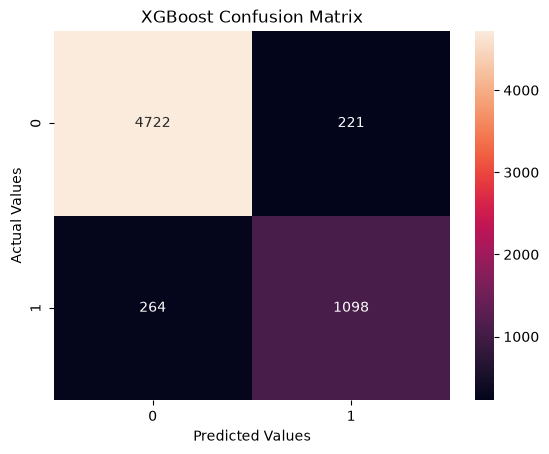

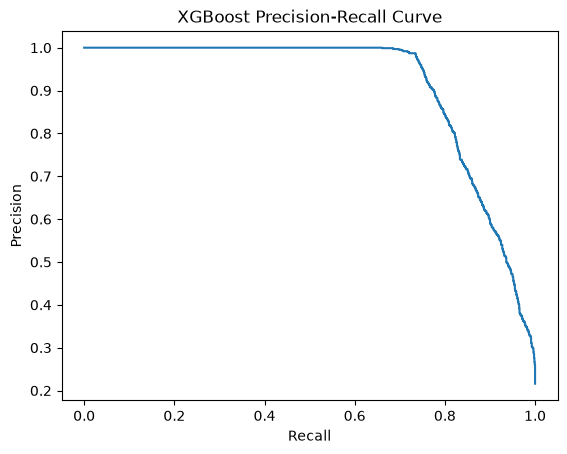

In [34]:
#Passing the XGBoost model after performing Hyperparameter Tuning
evaluate_model("XGBoost", random_search, X_test, y_test)

## 12. Optimizing the Classification Threshold
- The model gives a probability, not a direct yes or no.
- We decide a cut-off point to turn it into a decision.
- We check different cut-off points and pick the best one.

XGBoost Metrics:
Used Threshold : 0.76
Accuracy : 0.94
Precision : 0.98
Recall : 0.73
F1 : 0.84

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      4943
           1       0.98      0.73      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.96      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



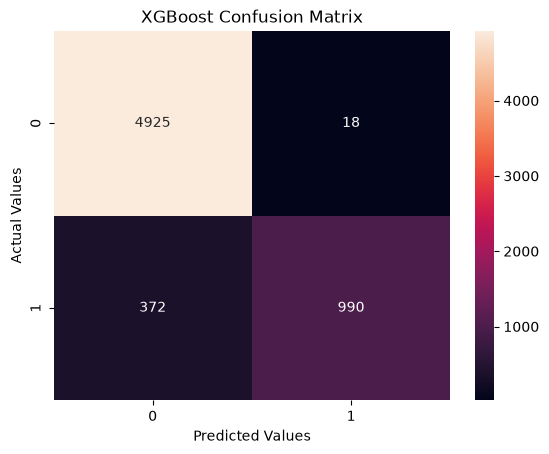

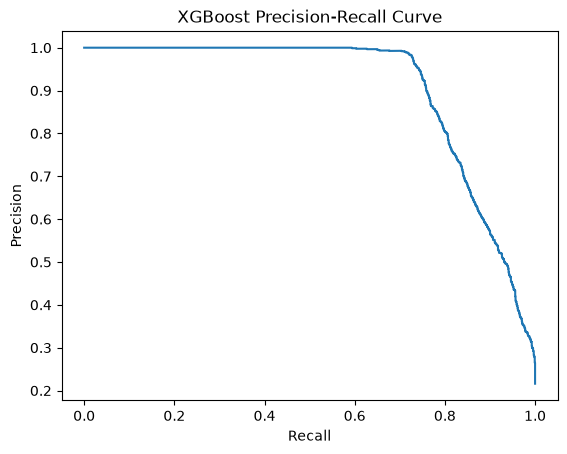

In [35]:
#Get the prob. of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

#For each threshold calculate Precision and Recall
precisions, recalls , thresholds = precision_recall_curve(y_test, prob)


#Calculate F1 score for each threshold
f1 = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

#Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

#Evaluate the XGBoost model using that threshold.
#Exploration only: this is the untuned, uncalibrated model scored on the test set.
#The threshold the API uses is chosen in section 13, on the calibrated model, without the test set.
evaluate_model("XGBoost", xg_model, X_test, y_test, best_threshold)

## 13. Probability Calibration
- Sometimes a model's probability doesn't mean what it says.
- For example, 30% risk should truly mean a 30% chance.
- We check this with a calibration plot.
- We fix it if the probabilities are off.

In [36]:
"""
Methods by which we can fix the poorly calibrated model.
1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.
2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)
3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature
"""

'\nMethods by which we can fix the poorly calibrated model.\n1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.\n2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)\n3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature\n'

In [37]:
#1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.0627471299151353),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=6,
                                                                max_leaves=None,
                                                                min_child_weight=4,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=435,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [38]:
#2. Get probabilites
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

### 13.1 Choosing the decision threshold the API uses
- The API applies the threshold to the **calibrated** model's probability, so it is chosen on that model.
- It is chosen on **out-of-fold predictions for the training set**, never on the test set, so the test scores below stay an honest estimate.
- The rule is the one `main.py` applies: `probability >= threshold` means High Risk.


Threshold chosen on training folds: 0.5692
Calibrated XGBoost Metrics:
Used Threshold : 0.57
Accuracy : 0.94
Precision : 0.93
Recall : 0.75
F1 : 0.84

Calibrated XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      4943
           1       0.93      0.75      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.94      0.87      0.90      6305
weighted avg       0.94      0.94      0.93      6305



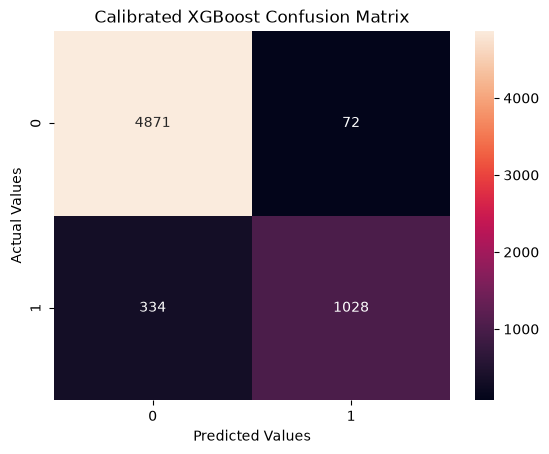

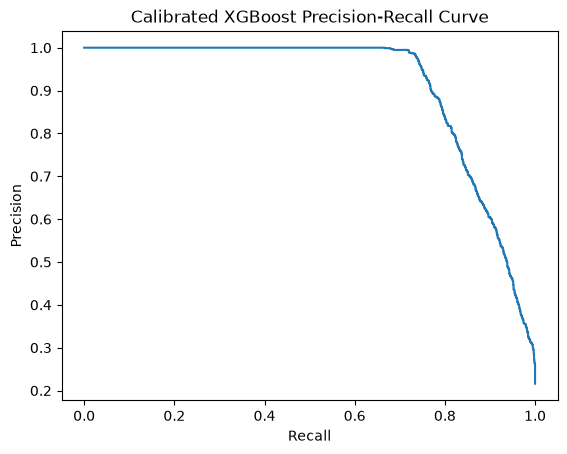

In [39]:
from sklearn.model_selection import cross_val_predict

#Out-of-fold calibrated probabilities for every training row
oof_prob = cross_val_predict(
    CalibratedClassifierCV(best_model, method="sigmoid", cv=5),
    X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_prob)
f1 = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = float(thresholds[np.argmax(f1[:-1])])
print(f"Threshold chosen on training folds: {best_threshold:.4f}")

#Now, and only now, the test set
evaluate_model("Calibrated XGBoost", calibrated_model, X_test, y_test, best_threshold)


In [40]:
#3. create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [41]:
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

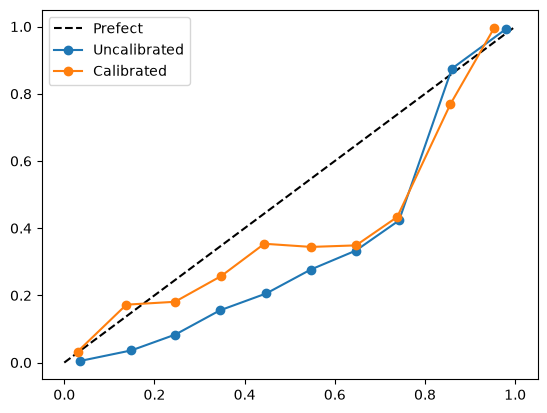

In [42]:
#4. plot
plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()

## 14. SHAP Interpretation — Global & Local
- SHAP helps us understand why the model makes a decision.
- It is a way of explaining a "black box" model.

In [43]:
#1. Install SHAP if not exists
!pip install shap
import shap

zsh:1: command not found: pip


/private/tmp/claude-501/-Users-sumitjadhav-portfolio/87809726-a65c-4ea3-bf5f-272507e05bb2/scratchpad/fix/credit-risk-ml-system/.venv-nb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [44]:
#2. Get the Trained XGBoost classifier model out of the pipeline.
xgb_classifier = xg_model.named_steps['classifier']

In [45]:
#3. Transform X_test using the same preprocessing used for training.
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [46]:
#4. Get feature names after one-hot enocding , so plots are readable
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [47]:
#5. Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

In [48]:
#6. Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)

In [49]:
#7. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.7525564e-01, -1.0555398e-01,  1.2984276e-01, ...,
        -7.3516304e-03, -3.8879905e-02,  0.0000000e+00],
       [ 4.7165070e-02, -8.7262326e-01, -9.4737314e-02, ...,
        -9.2151789e-03, -7.5508673e-03,  0.0000000e+00],
       [ 7.8027323e-02,  3.5025654e+00,  1.2711690e-01, ...,
        -7.3584518e-03,  7.7456667e-04,  0.0000000e+00],
       ...,
       [-8.6244931e-03,  5.8208090e-01,  7.2391242e-02, ...,
        -9.2837382e-03, -1.1459959e-02,  0.0000000e+00],
       [ 2.0838849e-02, -1.0313793e+00,  4.3692414e-02, ...,
        -9.2305308e-03, -1.1398583e-02,  0.0000000e+00],
       [-1.3665079e-01, -5.0866711e-01,  2.6854102e-02, ...,
        -8.8342456e-03, -1.0388625e-02,  0.0000000e+00]],
      shape=(6305, 26), dtype=float32)

### Global explanation
- This shows which features matter most overall.
- It also shows if a feature increases or decreases risk.

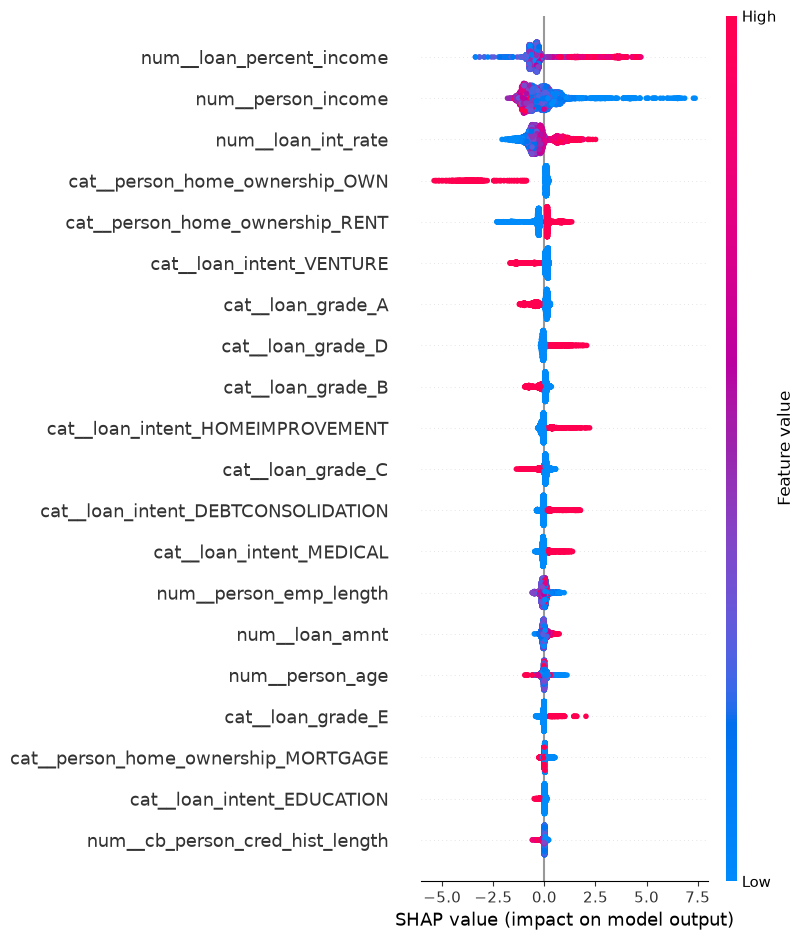

In [50]:
shap.summary_plot(shap_values, X_test_df)

### Local explanation
- This shows why one specific applicant got their score.
- It breaks the score down feature by feature.

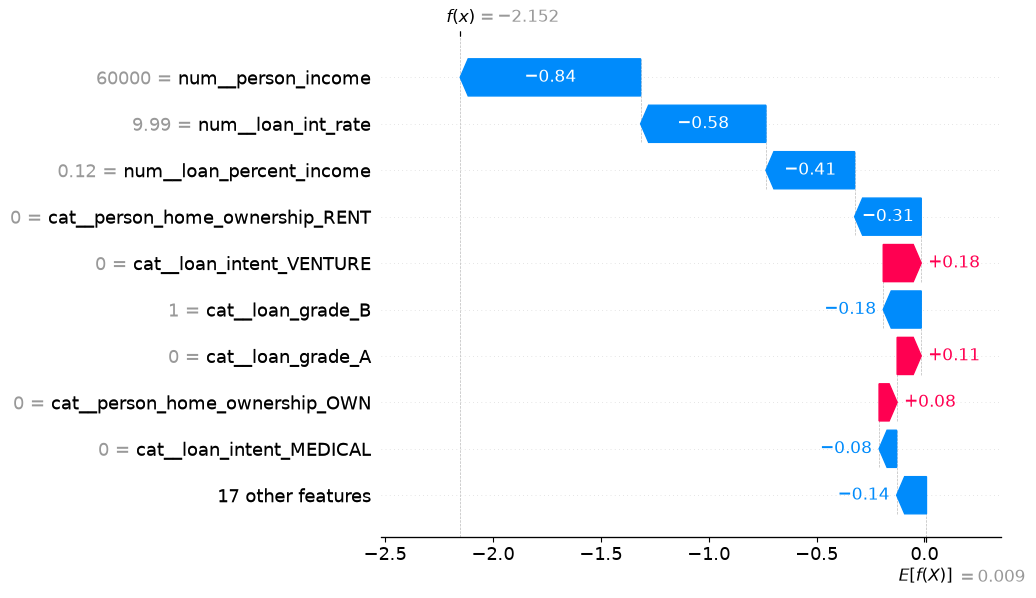

In [51]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

## 15. Analyzing False Positives & False Negatives
- The model will not be perfect.
- False positives are safe people wrongly marked risky.
- False negatives are risky people wrongly marked safe.
- We study these cases to understand where the model struggles.

In [52]:
#Get predictions from the best performing XGBoost model on the test set
y_pred = random_search.predict(X_test)

In [53]:
#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [54]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual']== 0) & (result_df['predicted']== 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]

In [55]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")

False Positive : 221
False Negative : 264


In [56]:
#False Negative > False Positive

## 16. Save the Final Model
- Once we are happy with the model, we save it.
- We also save the settings it needs, like the chosen threshold.
- This saved file can now be used in a real application.

In [57]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [58]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']